In [1]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_33_.csv') 

In [2]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch
"""
    Args:
        csv_data (str or filepath): Path to the CSV file or raw CSV string.
        num_vertices (int): Number of vertices per frame.
"""
import os, os.path

"""

class ClothDataset(Dataset):
    def __init__(self, csv_data, num_vertices=6):
       
        # Load the CSV data into a pandas DataFrame
        #if isinstance(csv_data, str) and "frame,x0" in csv_data:
            #self.data = pd.read_csv(io.StringIO(csv_data.strip()))
        #else:
            #self.data = pd.read_csv(csv_data)
        self.data = csv_data
            
        #quick fix para espacios en primera fila
        self.data.columns = self.data.columns.str.strip()
        
        self.num_vertices = num_vertices
        
        # Define the base feature names to extract per vertex
        self.feature_prefixes = ['x', 'y', 'z', 'sdf'] # 'vx', 'vy', 'vz',, 'nx', 'ny', 'nz', 'md', 'u', 'v'

        self.position_prefixes = ['x', 'y', 'z']
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')

        # Quitamos primera fila de outputs (no es el output de nada) y ultima fila de input (no tiene output)
        self.output_positions = self.output_positions.iloc[1:]
        self.data = self.data.iloc[:-1]
        

    def __len__(self):
        # The number of items is the number of frames (rows) in the dataset
        return len(self.data)
    
    def num_features(self):
        # Number of columns in a row (pos, vel, sdf, uv per vertex)
        return len(self.feature_prefixes)
    
    def num_vertex(self):
        return self.num_vertices
    
    def _get_frame_output_tensor(self, idx):
         row = self.output_positions.iloc[idx]
         frame_data = []
         for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.position_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

         tensor_data = torch.tensor(np.array(frame_data))

         return tensor_data
    
    def _get_frame_tensor(self, idx):
        row = self.data.iloc[idx]
        frame_data = []

        for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.feature_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

        tensor_data = torch.tensor(np.array(frame_data))

        return tensor_data
        
    def __getitem__(self, idx):
        frame_t = self._get_frame_tensor(idx)
        frame_t1 = self._get_frame_output_tensor(idx) # +1 ya no TODO: Pillar solo las columnas de pos

        return frame_t, frame_t1

"""

class ClothDataset(Dataset):
    def __init__(self, csv_data, num_vertices=6):
        self.data = csv_data
        self.data.columns = self.data.columns.str.strip()
        self.num_vertices = num_vertices
        
        # --- NUEVO: Guardamos el Frame 0 como referencia absoluta ---
        # Extraemos las posiciones x, y, z del primer frame únicamente
        self.pos_prefixes = ['x', 'y', 'z']
        self.rest_pose = self.data.iloc[0].filter(regex=r'^[xyz]\d+$').values.astype(np.float32)
        
        # Filtramos las columnas de SDF (que sí cambian en cada frame)
        self.sdf_cols = [f"sdf{i}" for i in range(self.num_vertices)]
        
        # El target será la posición real en el frame T
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. INPUT: Combinamos Posiciones Originales (Fijas) + SDF Actual (Variable)
        # rest_pose: [x0, y0, z0, x1, y1, z1...] del Frame 0
        # sdf_t: [sdf0, sdf1, sdf2...] del Frame actual
        sdf_t = self.data.iloc[idx][self.sdf_cols].values.astype(np.float32)
        
        # Reorganizamos para que cada vértice tenga [x0, y0, z0, sdf_t]
        frame_input = []
        for i in range(self.num_vertices):
            # Posición original del vértice i (del frame 0)
            v_orig = self.rest_pose[i*3 : i*3 + 3]
            # SDF actual del vértice i (del frame idx)
            v_sdf = sdf_t[i]
            frame_input.append(np.append(v_orig, v_sdf))
            
        # 2. TARGET: Desplazamiento TOTAL desde el origen
        # Target = Posición_Actual(t) - Posición_Original(0)
        pos_t = self.output_positions.iloc[idx].values.astype(np.float32)
        total_delta = pos_t - self.rest_pose
        
        # Reshape a (Vértices, 3) para que coincida con tu modelo
        return torch.tensor(frame_input), torch.tensor(total_delta.reshape(-1, 3))

# --- Example Usage ---

# (Assuming 'csv_string' is a variable holding your provided data block)
dataset = ClothDataset(df)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_data, batch_frames in dataloader:
    print(f"Batch Shape: {batch_data.shape}")
    print(batch_data)
    print(batch_frames)
    break



<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Eva\AppData\Local\Temp\ipykernel_10108\560015226.py:11: SyntaxWarning: invalid escape sequence '\d'
  """


Batch Shape: torch.Size([4, 6, 4])
tensor([[[ 0.0000e+00,  6.8191e-05, -2.2553e-01,  9.1525e-01],
         [ 0.0000e+00, -5.0002e-01,  2.2545e-01,  9.1476e-01],
         [ 0.0000e+00, -5.0000e-01, -2.2553e-01,  8.7264e-01],
         [ 0.0000e+00,  5.8850e-05,  2.2556e-01,  9.7292e-01],
         [ 0.0000e+00,  5.0000e-01, -2.2550e-01,  1.1079e+00],
         [ 0.0000e+00,  5.0000e-01,  2.2550e-01,  1.1631e+00]],

        [[ 0.0000e+00,  6.8191e-05, -2.2553e-01,  6.8790e-01],
         [ 0.0000e+00, -5.0002e-01,  2.2545e-01,  8.0875e-01],
         [ 0.0000e+00, -5.0000e-01, -2.2553e-01,  7.7834e-01],
         [ 0.0000e+00,  5.8850e-05,  2.2556e-01,  7.4589e-01],
         [ 0.0000e+00,  5.0000e-01, -2.2550e-01,  9.4083e-01],
         [ 0.0000e+00,  5.0000e-01,  2.2550e-01,  1.0021e+00]],

        [[ 0.0000e+00,  6.8191e-05, -2.2553e-01,  6.0509e-02],
         [ 0.0000e+00, -5.0002e-01,  2.2545e-01, -2.4718e-02],
         [ 0.0000e+00, -5.0000e-01, -2.2553e-01, -2.5656e-01],
         [ 0.000

C:\Users\Eva\AppData\Local\Temp\ipykernel_10108\560015226.py:124: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  return torch.tensor(frame_input), torch.tensor(total_delta.reshape(-1, 3))


In [3]:
import torch.nn as nn
import torch.nn.functional as F #acceso rapido a funciones
import torch.utils.data as data #cargar y manejar el training data
"""
class MyModule(nn.Module): # Versión base # Si se vuelve a poner esto hay que cambiar abajo la entrada del modelo a 4, 64 o lo que sea (neuronas), 3

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Some init for my module
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Function for performing the calculation of the module.
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        #print(x)
        return x

class MyModule(nn.Module): # Versión más grande
    def __init__(self, num_verts, num_feats):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_verts * num_feats, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, num_verts * 3) # Predice x,y,z para todos los vértices
        )
    def forward(self, x):
        # x llega como (Batch, Vértices, Features) -> (Batch, 6, 4)
        # Lo aplanamos para que sea (Batch, 24)
        x = x.view(x.size(0), -1) 
        x = self.net(x)
        # Devolvemos la forma original (Batch, 6, 3) para que el Loss funcione igual
        return x.view(x.size(0), -1, 3)
    #backward se hace automaticamente, podriamos definirla tmbn 
 """
class SubspaceMLP(nn.Module):
    def __init__(self, input_dim=24, latent_dim=4): # 24 = 6 verts * 4 feats
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, latent_dim) # Output: Coeficientes PCA (z)
        )

    def forward(self, x):
        # x: (Batch, 6, 4) -> (Batch, 24)
        x = x.view(x.size(0), -1)
        z = self.net(x) 
        return z
        return x.view(x.size(0), -1, 3) # Output: (Batch, 6, 3)
#tmbn clases DataSet y DataLoader

# definir modelo, loss function y optimizer
#TODO: buscar dimensiones reales de las neuronas

# nn.Linear in PyTorch is designed to handle 3D tensors seamlessly.  
# When a 3D input tensor (e.g., batch_size, sequence_length, features) is provided,
#  the layer applies the linear transformation only to the last dimension (the features dimension),
#  preserving all other dimensions.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import json
from sklearn.decomposition import PCA

# --- 1. CONFIGURACIÓN Y DATALOADERS ---
# Asegúrate de que 'dataset' esté definido antes
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(dataset, batch_size=4, shuffle=False)

num_verts = 6
num_components = 4 # Espacio latente de Ubisoft

# --- 2. CÁLCULO DE PCA Y POSE PROMEDIO (OFFLINE) ---
print("Calculando Subespacio PCA...")
all_positions = []
for _, batch_t1 in DataLoader(dataset, batch_size=1):
    all_positions.append(batch_t1[:, :, 0:3].reshape(1, -1).numpy())

all_positions = np.concatenate(all_positions, axis=0) # (Frames, 18)
mean_pose_np = np.mean(all_positions, axis=0)
mean_pose_tensor = torch.from_numpy(mean_pose_np).float()

pca_engine = PCA(n_components=num_components)
pca_engine.fit(all_positions - mean_pose_np)
u_matrix_tensor = torch.from_numpy(pca_engine.components_).float() # (4, 18)

# Guardamos el Frame 0 para usarlo como "Rest Pose" en el input
rest_pose_input = torch.from_numpy(all_positions[0].reshape(6, 3)).float()

# --- 3. ESTADÍSTICAS DE NORMALIZACIÓN (INPUT) ---
print("Calculando normalización de entrada...")
all_inputs = []

# Aseguramos que rest_pose_input sea (6, 3)
rest_pose_input_2d = rest_pose_input.view(6, 3)

for batch_t, batch_t1 in DataLoader(dataset, batch_size=1):
    # sdf tiene forma (1, 6, 1)
    sdf = batch_t1[:, :, 3:4].view(6, 1) 
    
    # Concatenamos (6, 3) con (6, 1) -> Resultado (6, 4)
    x_in = torch.cat([rest_pose_input_2d, sdf], dim=-1)
    
    # Ahora sí, guardamos como (6, 4)
    all_inputs.append(x_in) # x_in ya tiene el shape correcto (6, 4)

full_input_tensor = torch.stack(all_inputs) # (Frames, 6, 4)
input_mean = full_input_tensor.view(-1, 4).mean(dim=0)
input_std = full_input_tensor.view(-1, 4).std(dim=0)

# --- 4. MODELO Y ENTRENAMIENTO ---
class SubspaceMLP(nn.Module):
    def __init__(self, input_dim=24, latent_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, latent_dim)
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

model = SubspaceMLP(input_dim=num_verts*4, latent_dim=num_components)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss() # Para PCA, MSE suele converger más rápido

print("Empezando entrenamiento...")
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for _, batch_t1 in train_loader:
        b_size = batch_t1.size(0)
        # Expandimos la pose de reposo al tamaño del batch: (Batch, 6, 3)
        p0 = rest_pose_input.view(6, 3).unsqueeze(0).expand(b_size, -1, -1)
        sdf = batch_t1[:, :, 3:4] # (Batch, 6, 1)
        if sdf.shape[2] == 0:
            raise ValueError("Error: El tensor de SDF está vacío. Revisa los índices de tus columnas.")
        # Concatenamos para obtener (Batch, 6, 4)
        x_raw = torch.cat([p0, sdf], dim=-1).float()
        
        # Normalizar
        x_norm = (x_raw - input_mean) / input_std
        
        # Predicción y Reconstrucción
        z_pred = model(x_norm)
        q_pred = mean_pose_tensor + torch.matmul(z_pred, u_matrix_tensor)
        
        # Loss
        q_real = batch_t1[:, :, 0:3].reshape(b_size, -1).float()
        loss = criterion(q_pred, q_real)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.6f}")

# --- 5. EXPORTACIÓN PARA UNITY (JSON) ---
print("Exportando parámetros para Unity...")
unity_params = {
    "input_mean": input_mean.tolist(),
    "input_std": input_std.tolist(),
    "mean_pose": mean_pose_np.tolist(),
    "pca_matrix": pca_engine.components_.tolist(), # La matriz U
    "rest_pose_input": rest_pose_input.view(-1).tolist()
}

with open("unity_cloth_params.json", "w") as f:
    json.dump(unity_params, f)

# Exportar modelo ONNX
dummy_input = torch.randn(1, 6, 4)
torch.onnx.export(model, dummy_input, "SubspaceCloth.onnx")
print("¡Todo listo! Modelo y parámetros exportados.")

Calculando Subespacio PCA...
Calculando normalización de entrada...


RuntimeError: shape '[6, 1]' is invalid for input of size 0

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

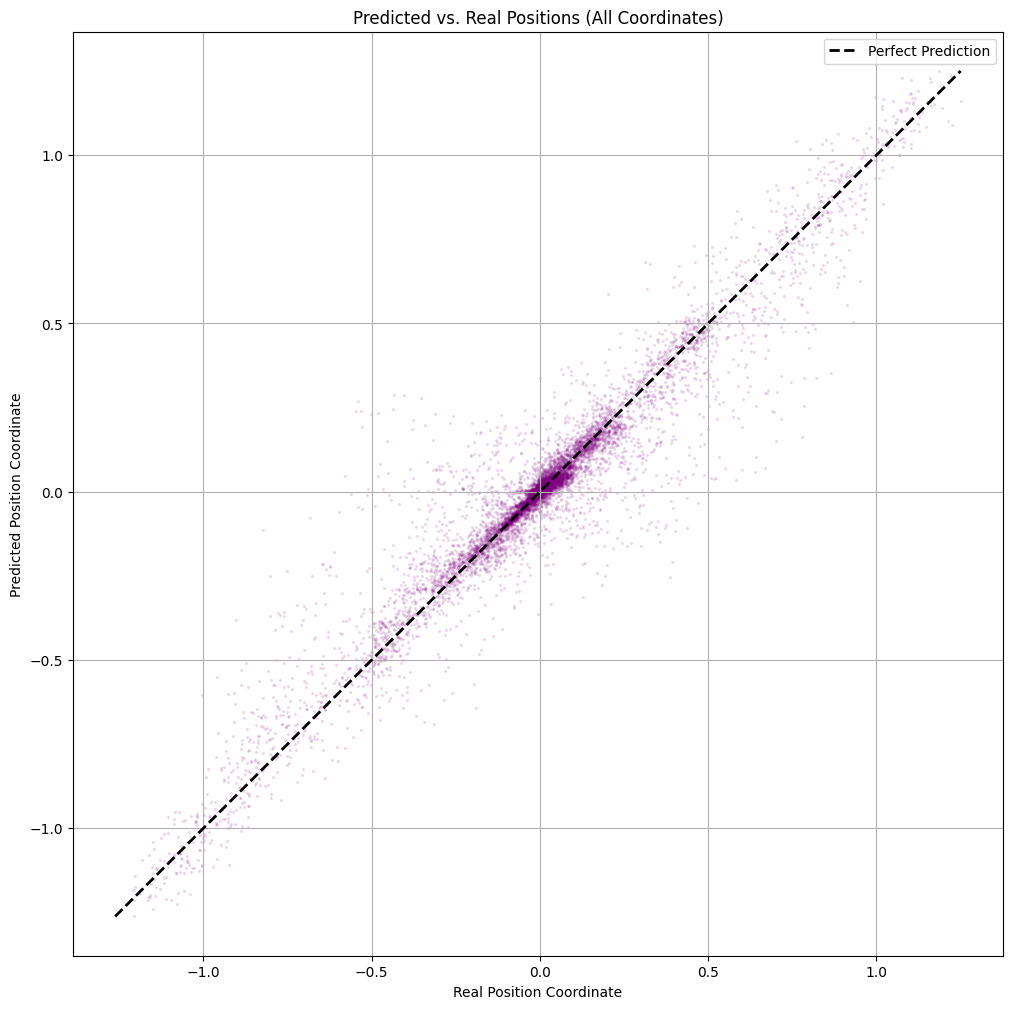

In [ ]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

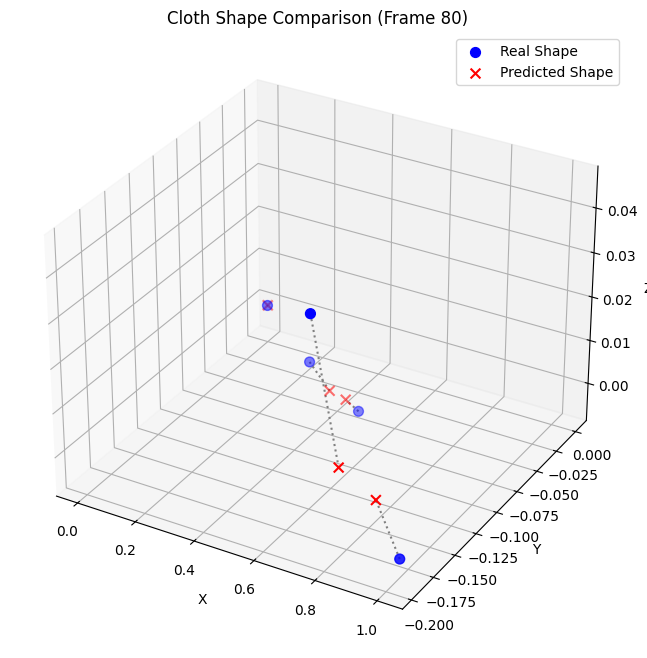

In [ ]:
# Choose a random frame from your test set to visualize
frame_idx = 80# Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [ ]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. Create a dummy input strictly enforcing the 3D shape: (Batch=3, Vertices=6, Features=13)
# It doesn't matter what the numbers are, ONNX just needs the shape.
dummy_input = torch.randn(1, 6, 4)

# 3. Export to ONNX
onnx_program = torch.onnx.export(
    model,                      # Your trained PyTorch model
    dummy_input,                # The strictly 3D input tensor
    "cloth_pos_local.onnx",         # Output file name
    export_params=True,         # Store the trained weights
    opset_version=9,            # Sentis handles opset 9-15 well
    input_names=['input'],      # Name the input for Unity
    output_names=['output'],    # Name the output for Unity
)

print("Exported to ONNX with strict 3D shapes!")

# Mantenemos la forma (1, 6, 4) porque el .view(-1) dentro del modelo se encarga del resto
dummy_input = torch.randn(1, 6, 4) 

torch.onnx.export(
    model, 
    dummy_input, 
    "cloth_global_model.onnx",
    input_names=['input'],
    output_names=['output'],
    # Esto es clave si en Unity quieres usar más o menos de 1 tela a la vez
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

Exported to ONNX with strict 3D shapes!
